 TELECOM CHURN PREDICTION

In [1]:
# import the following libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
tel_base_data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
tel_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# check the various attributes of the data like shape rows and columns

In [5]:
tel_base_data.shape

(7043, 21)

In [6]:
tel_base_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [7]:
# Check the datatypes
tel_base_data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
# check for the descriptive statistics of the numerical value
tel_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


senior citizen is actually a categorical hence the 25%-50%-75% distribution is not proper

75% customer have tenure less than 55 months 

Average monthly charges are USD 64.76 whereas 25% customer pay more than USD 89.85 per month 

Text(0.5, 1.02, 'count of TARGET Variable per category')

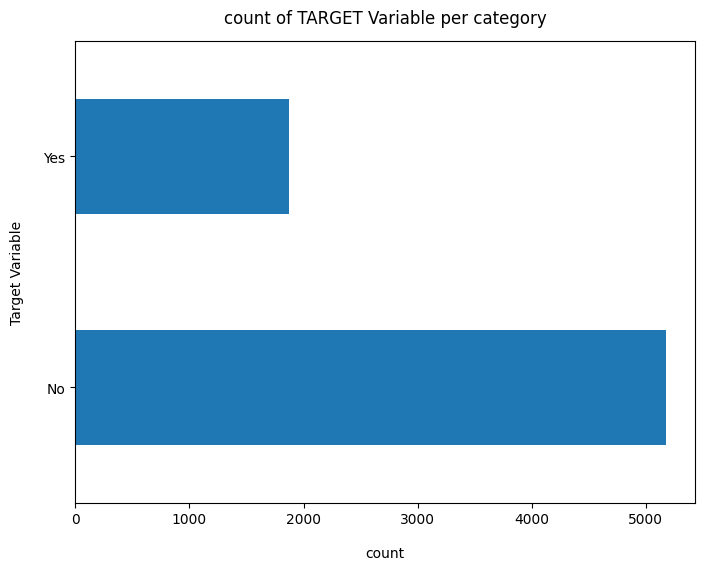

In [9]:
tel_base_data['Churn'].value_counts().plot(kind= 'barh', figsize=(8, 6))
plt.xlabel("count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("count of TARGET Variable per category", y=1.02)

In [10]:
100*tel_base_data['Churn'].value_counts()/len(tel_base_data['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [11]:
tel_base_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

* Data is highly imbalanced rato = 73.27
* So we analyse the data with other features while taking the target values seperately to get some insights

In [12]:
# concise summary of th dataframe, as we have too many columns,we are using the verbrose = true mode
tel_base_data.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


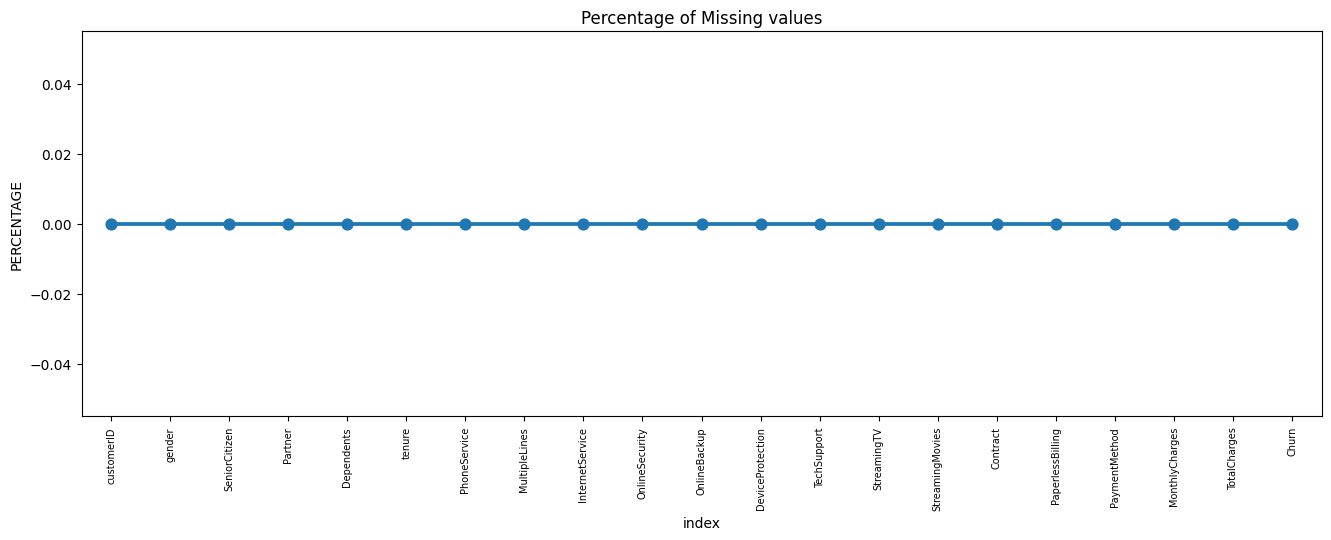

In [13]:
missing = pd.DataFrame((tel_base_data.isnull().sum())*100/tel_base_data.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation =90, fontsize =7)
plt.title('Percentage of Missing values')
plt.ylabel('PERCENTAGE')
plt.show()

Missing Data - Initial Intuition
* Here we dont have missing data

General Thumb Rules
* For features with less mising values can use regression to predict the missin values or fill with the mean of the values present, depending on the feature.
* for features with very high number of missing values - it is better to drop those columns as they give very leass insight on analysis 
* As theres no thumb rule on what criteria do we delete the columns with high number of missing values, but generally you can delete the columns, if you have more than 30% - 40% of missing values. But again there is a catch here. for example, is_car &car_type, people having no cars, will obviously have car_type as NaN (Null), but that doesnt make this column useless, so decisions has to be taken wisely

Data Cleaning

1. Create a copy of base data for manipulation and processing

In [14]:
tel_data = tel_base_data.copy()

2. Total Charges should be numerical amount. Let convert it to numerical data type

In [15]:
tel_data.TotalCharges = pd.to_numeric(tel_data.TotalCharges, errors='coerce')
tel_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

3. As we can see there are 11 missin values in TotalCharges column. Let's check these records

In [16]:
tel_data.loc[tel_data ['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


since the % of these records compared to the total dataset is very low is 0.15%. it is safe to ignore them from further processing.

In [17]:
#Removing missing values
tel_data.dropna(how = 'any', inplace = True)

#tel_data.fillna(0)

5. Divide customers into bins based on tenure e.g for tenure < 12 months assign a tenure group if 1-12, for tenure between 1 to 2 years, tenure group of 13-24 , so on...

In [18]:
#get the max tenure 
print(tel_data['tenure'].max())

72


In [19]:
#group the tenure in bins of 12 months
labels = ["({}) - ({})".format(i, i + 11) for i in range(1, 72, 12)]

tel_data['tenure_group'] = pd.cut(tel_data.tenure, range(1, 80, 12), right=False, labels=labels)

In [20]:
tel_data['tenure_group'].value_counts()

tenure_group
(1) - (12)     2175
(61) - (72)    1407
(13) - (24)    1024
(25) - (36)     832
(49) - (60)     832
(37) - (48)     762
Name: count, dtype: int64

In [21]:
#drop column customerid and tenure
tel_data.drop(columns = ['customerID', 'tenure'], axis=1, inplace=True)
tel_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,(1) - (12)
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,(25) - (36)
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,(1) - (12)
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,(37) - (48)
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,(1) - (12)


Data Exploration 
1. plot distribution of individual predictors by churn

Univariate Analysis

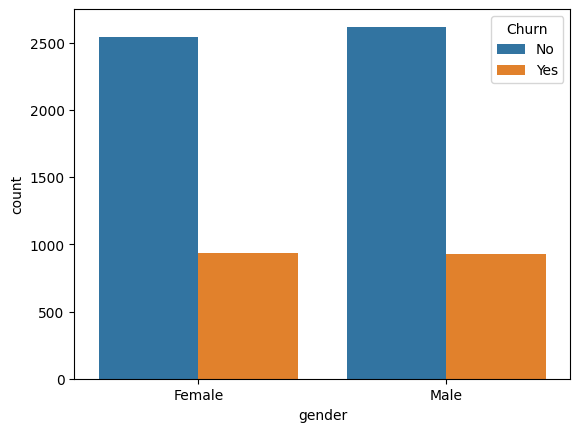

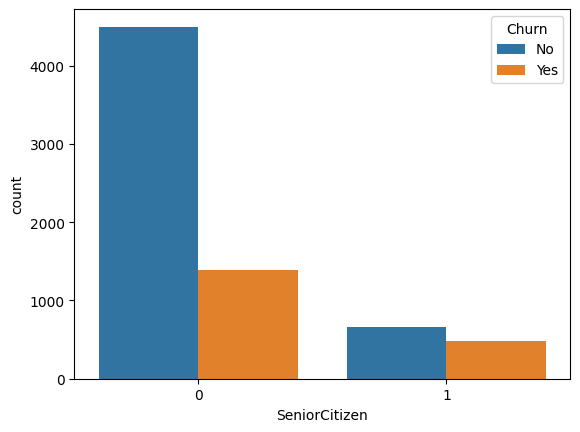

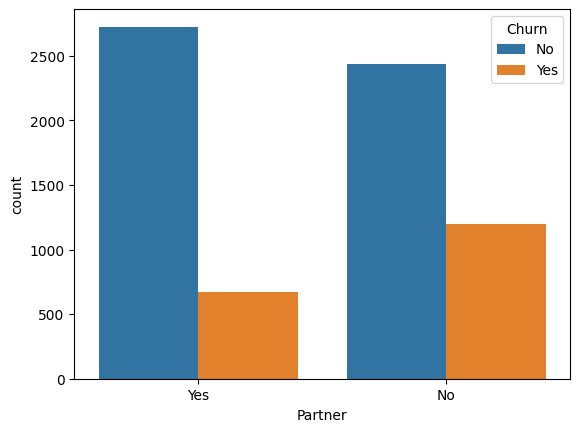

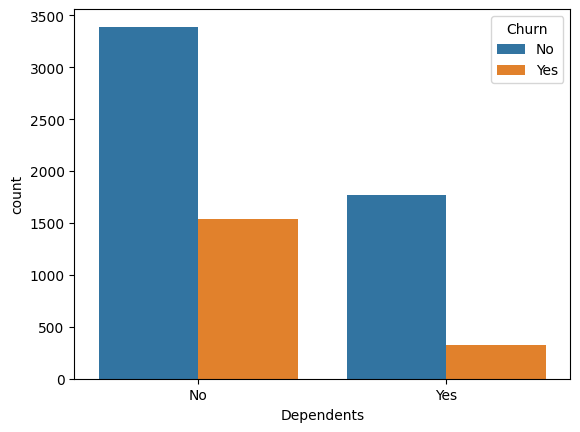

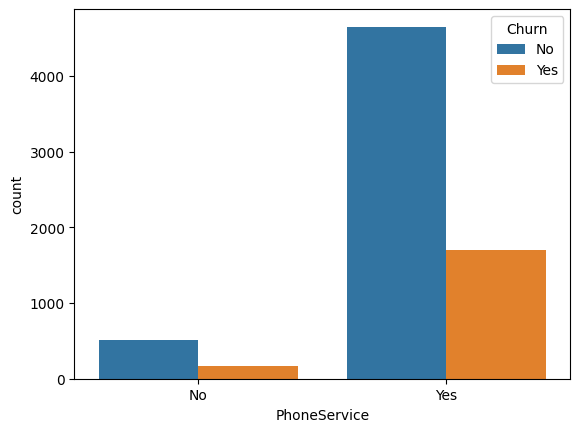

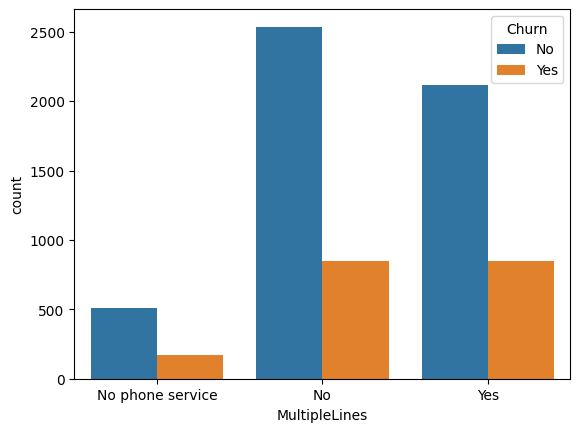

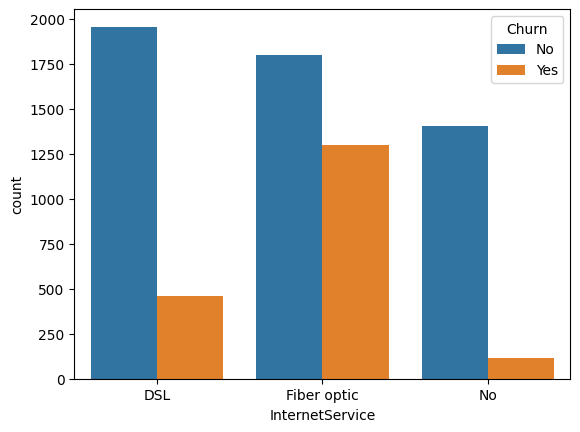

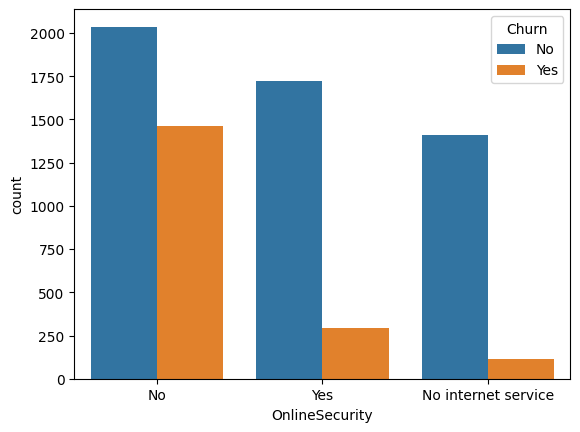

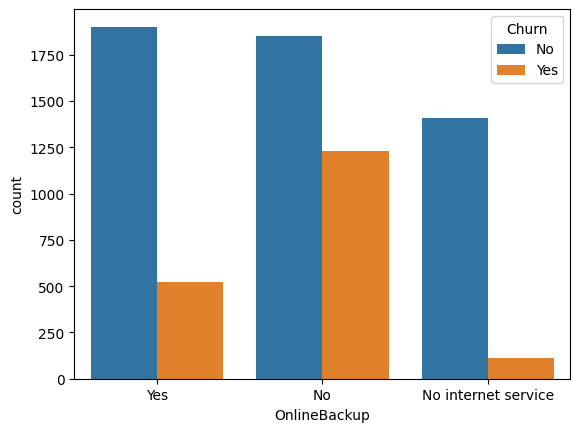

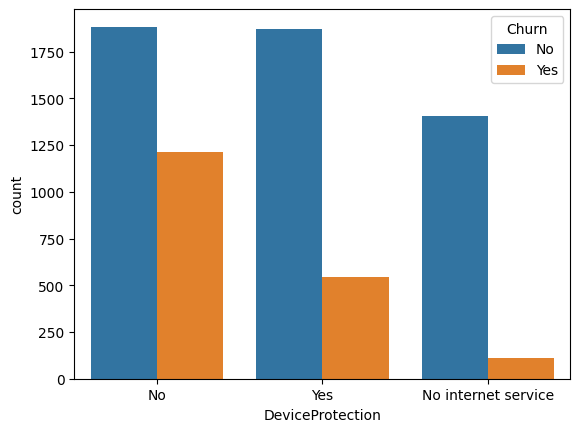

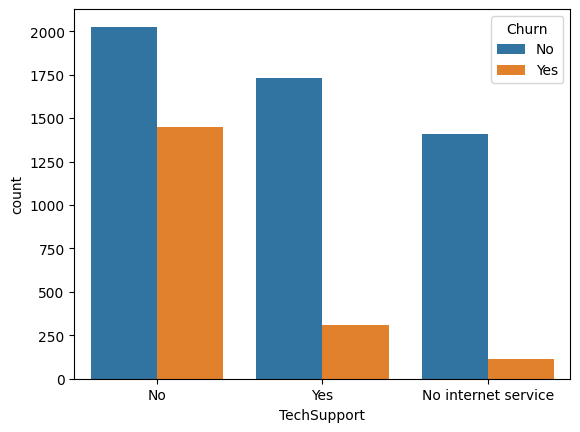

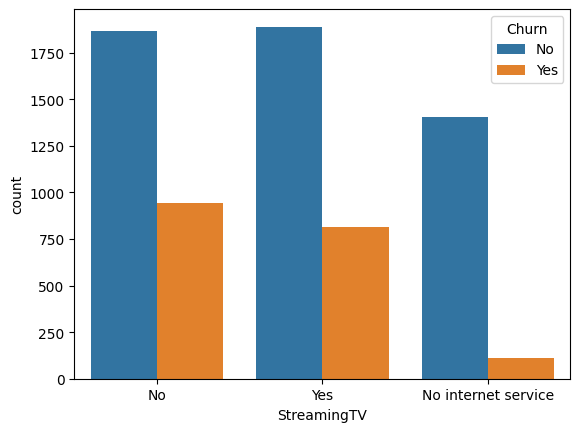

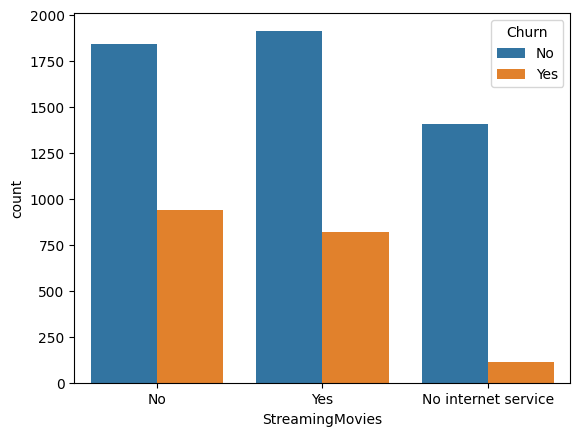

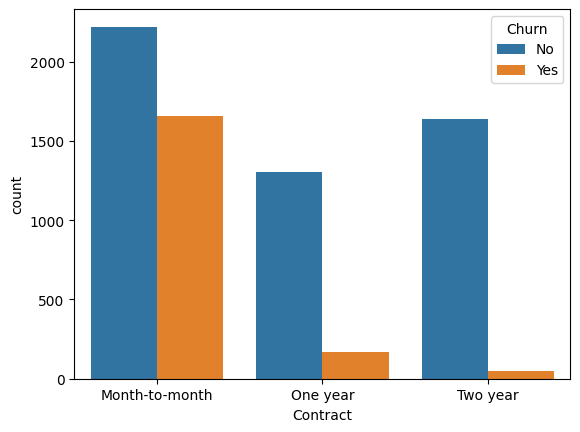

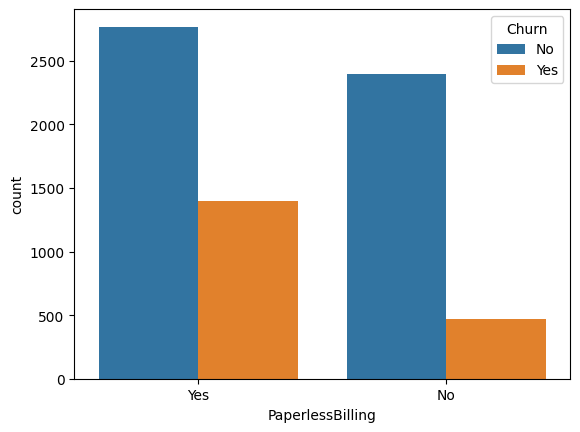

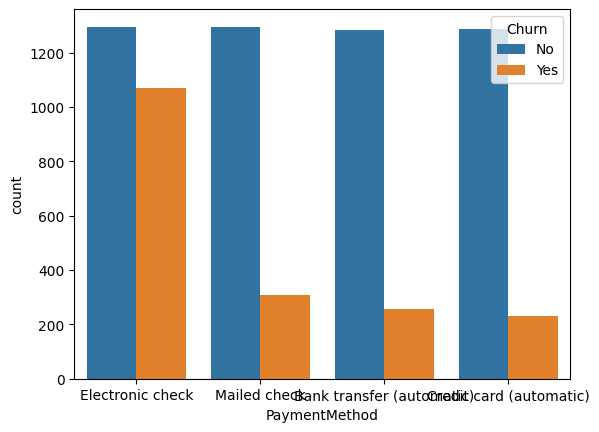

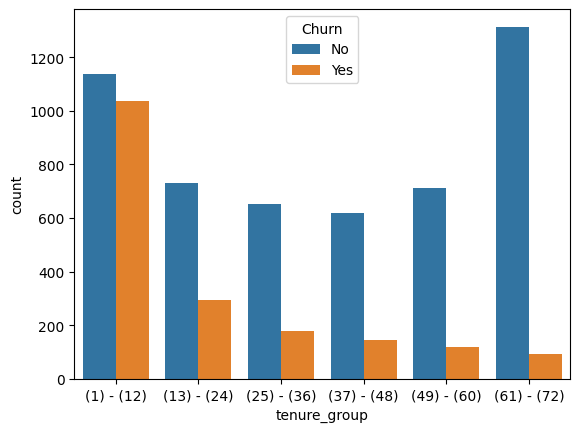

In [22]:
for i, predictor in enumerate(tel_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data=tel_data, x=predictor, hue='Churn')

convert the target variables 'churn' in a binary numeric variable i.e yes=1: no =0

In [23]:
tel_data['Churn'] = np.where(tel_data.Churn == 'Yes',1,0)

tel_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,(1) - (12)
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,(25) - (36)
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,(1) - (12)
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,(37) - (48)
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,(1) - (12)


3. convert all the categorical variables into dummy variables

In [24]:
tel_data_dummies = pd.get_dummies(tel_data)
tel_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_(1) - (12),tenure_group_(13) - (24),tenure_group_(25) - (36),tenure_group_(37) - (48),tenure_group_(49) - (60),tenure_group_(61) - (72)
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


Relationship between monthly charges and total charges

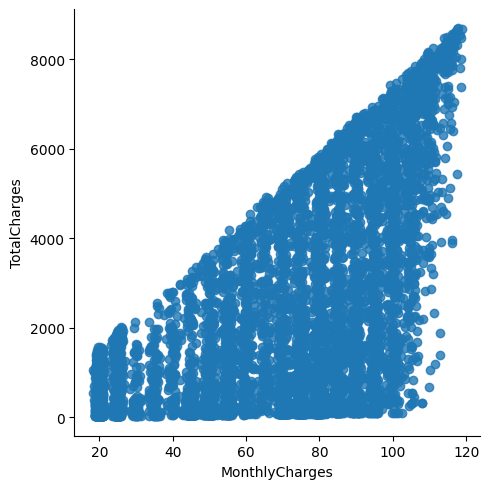

In [25]:
sns.lmplot(data=tel_data_dummies, x='MonthlyCharges', y= 'TotalCharges', fit_reg=False)

total charges increases as monthly charges increase - as expected

10. churn by monthly charges and total charges

Text(0.5, 1.0, 'Monthly charges by churn')

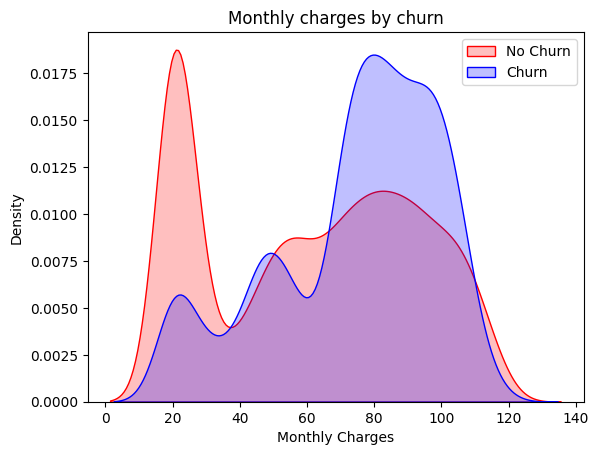

In [26]:
Mth = sns.kdeplot(tel_data_dummies.MonthlyCharges[(tel_data_dummies['Churn'] == 0) ],
                  color= "Red", fill = True)
Mth = sns.kdeplot(tel_data_dummies.MonthlyCharges[(tel_data_dummies['Churn'] == 1) ],
                  ax =Mth, color="Blue", fill= True)
Mth.legend(["No Churn", "Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

Insight: churn is high when monthly charges is high

Text(0.5, 1.0, 'Monthly charges by churn')

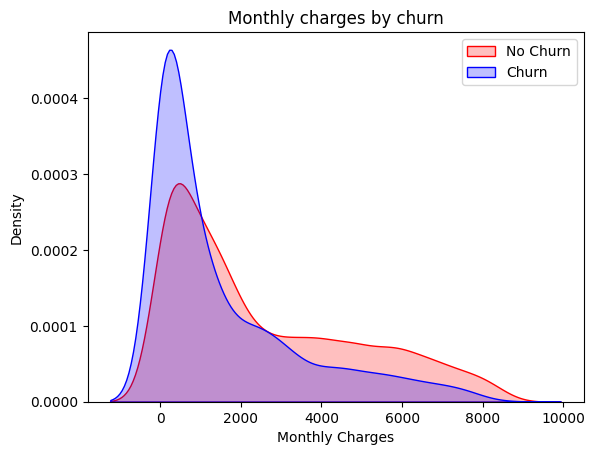

In [27]:
Tot = sns.kdeplot(tel_data_dummies.TotalCharges[(tel_data_dummies['Churn'] == 0) ],
                  color= "Red", fill = True)
Tot = sns.kdeplot(tel_data_dummies.TotalCharges[(tel_data_dummies['Churn'] == 1) ],
                  ax =Tot, color="Blue", fill= True)
Tot.legend(["No Churn", "Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Monthly Charges')
Tot.set_title('Monthly charges by churn')

surprising insights as higher churn at lower total charges

however if we combine the insights of 3 parameters i.e Tenure, Monthly Charges and Total Charges then the picture is bit clear 

higher monthly charge at lower tenure results into lower total charge. Hnece, all these 3 factors viz Higher Monthly charge lower tenure and lower total charge are likned to high churn

11. build a correlation of all predictors with churn

<Axes: >

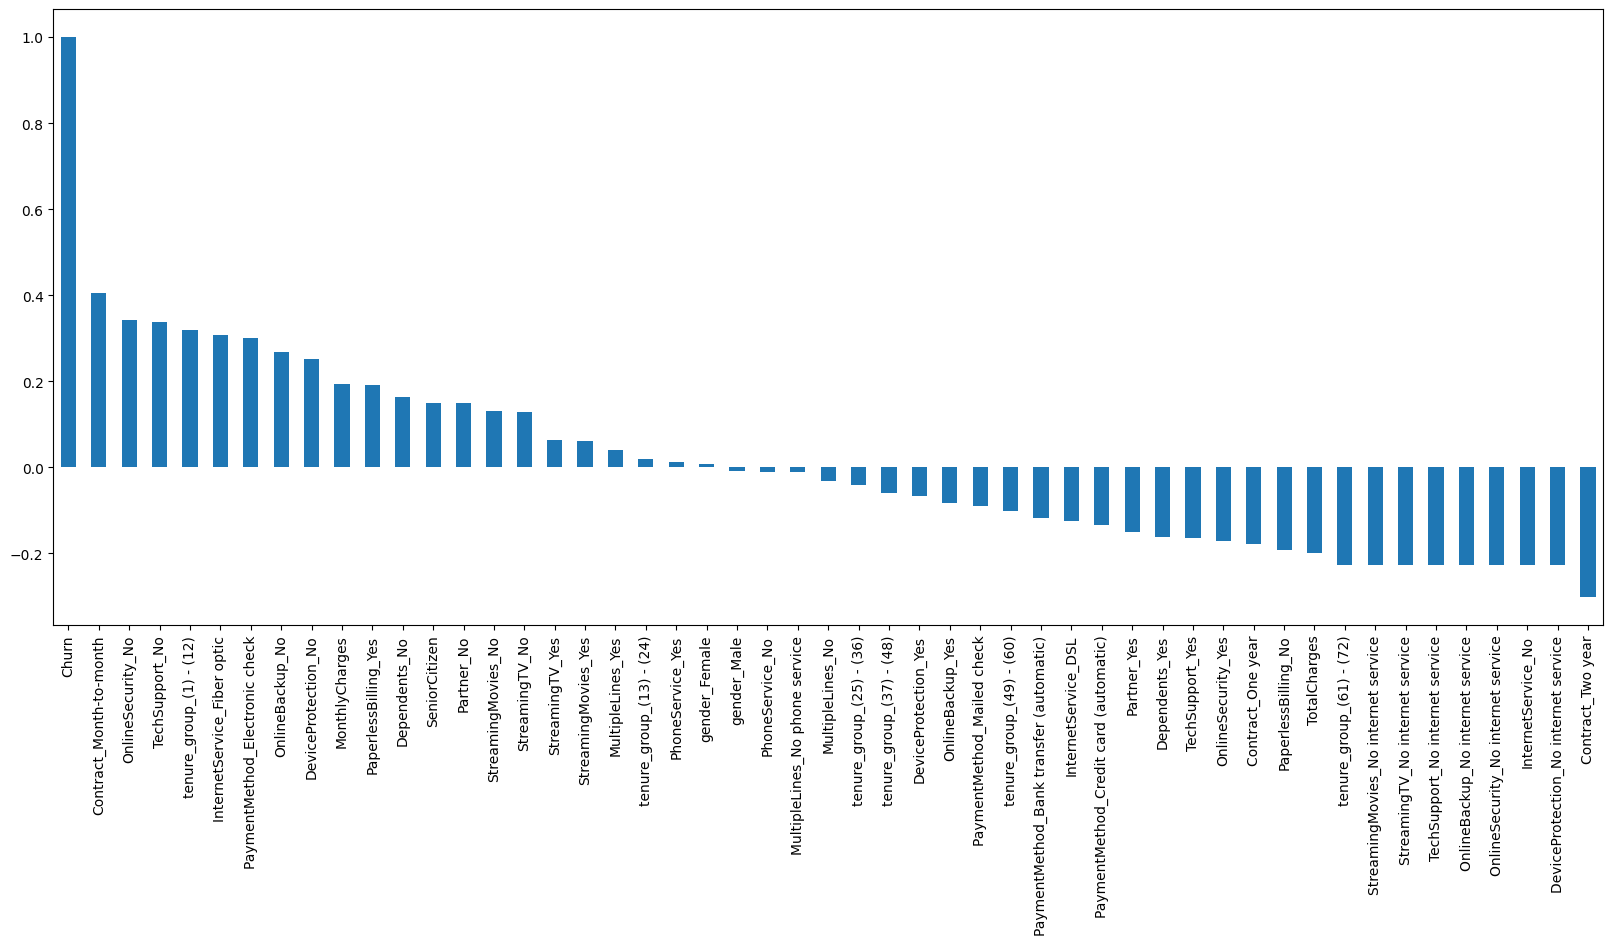

In [28]:
plt.figure(figsize=(20,8))
tel_data_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

Derived insights 

High Churn seen in case of month to month contracts. No online security. No tech support. final year subscription and fibre optics internet 

Low Churn is seen in case of long contracts, subscriptions without internet service and the customers engaged for 5+ years

factors like Gender, Availabilty of phone service and # of multiple lines have almost NO impact on churn

This is also evident from heatmap below

<Axes: >

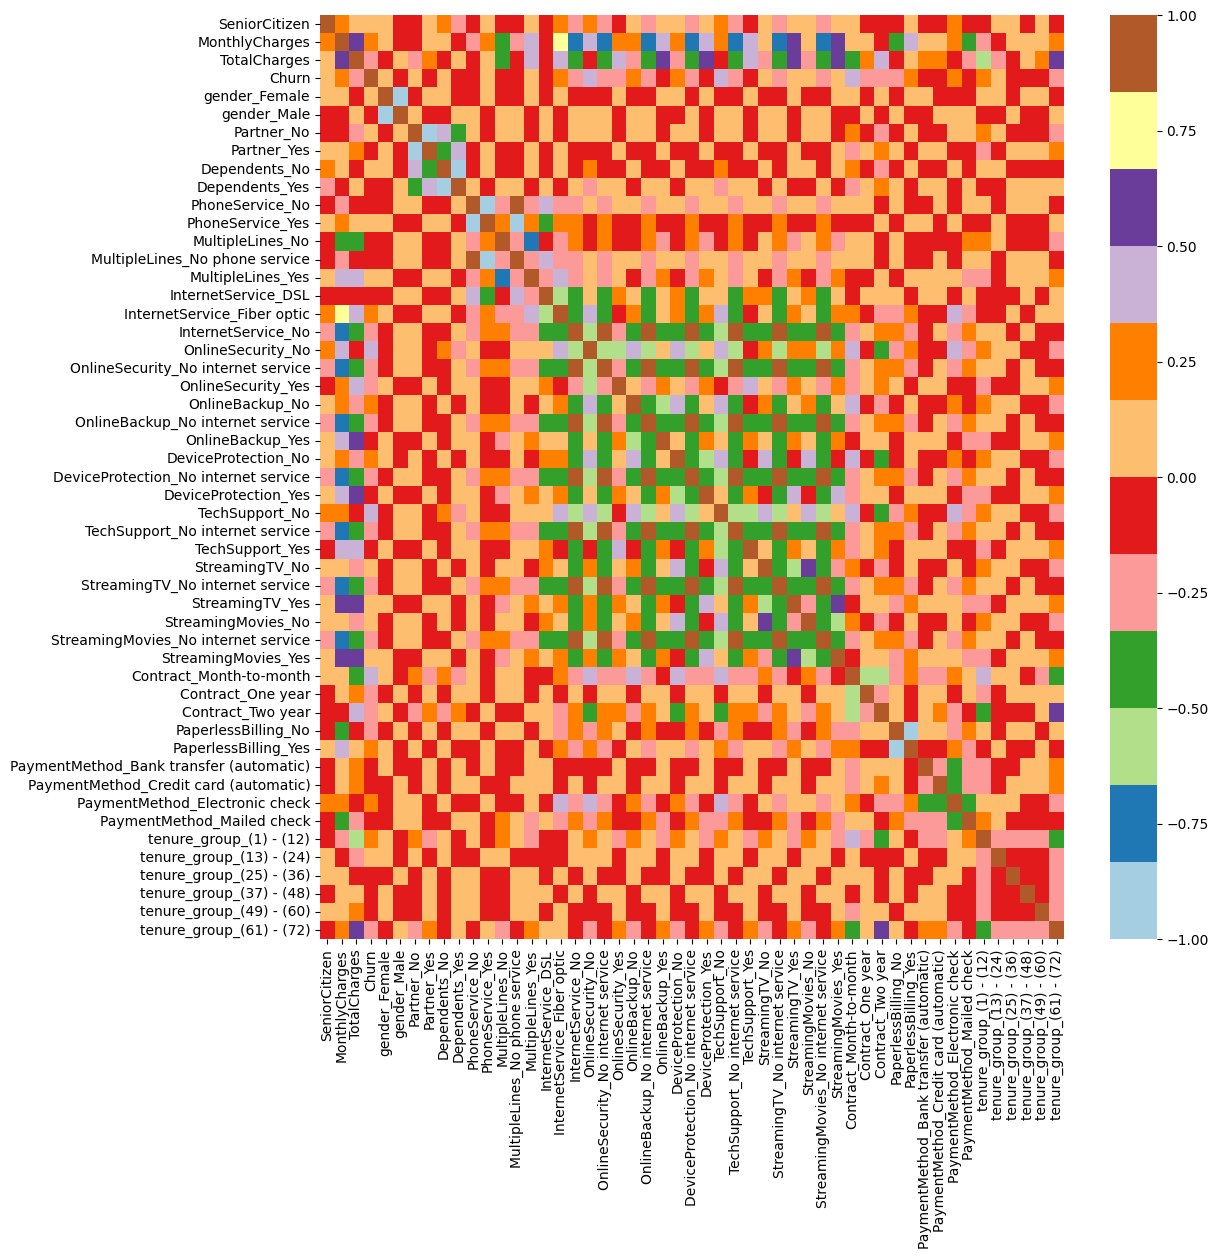

In [29]:
plt.figure(figsize=(12,12))
sns.heatmap(tel_data_dummies.corr(), cmap="Paired")

Bivariate analysis

In [30]:
new_df1_target0=tel_data.loc[tel_data['Churn']==0]
new_df1_target1=tel_data.loc[tel_data['Churn']==1]

In [59]:
from matplotlib.ticker import ScalarFormatter
def uniplot(df, col, title, hue=None, auto_log=True):
    """
    Plots a bivariate countplot (categorical vs categorical) with optional hue.
    
    Parameters:
    - df: pandas DataFrame
    - col: str, column name to plot on x-axis
    - title: str, plot title
    - hue: str or None, column for hue
    - auto_log: bool, automatically use log scale if max count > 1000
    """
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    # Prepare hue values
    temp = df[hue] if hue else pd.Series([])
    hue_count = len(temp.unique()) if hue else 0

    # Dynamic figure width
    width = len(df[col].unique()) + 7 + 4 * hue_count
    fig, ax = plt.subplots(figsize=(width, 8))

    # Plot
    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright'
    )

    # Auto log scale for very large counts
    max_count = df[col].value_counts().max()
    if auto_log and max_count > 1000:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ScalarFormatter())  # nicer labels

    # Title and labels
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


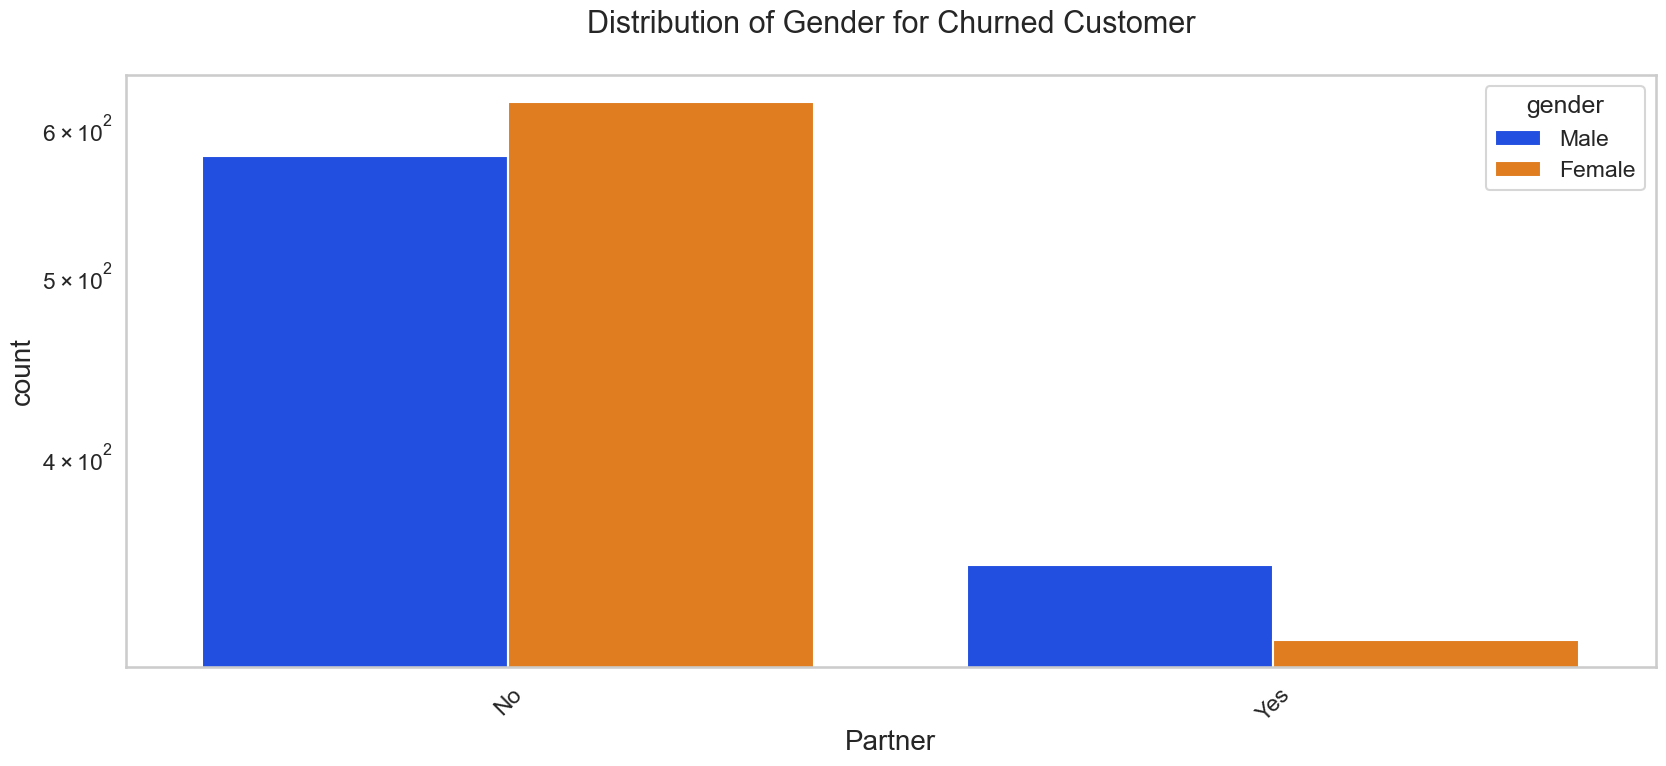

In [60]:
uniplot(new_df1_target1,col='Partner',title='Distribution of Gender for Churned Customer',hue='gender')

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


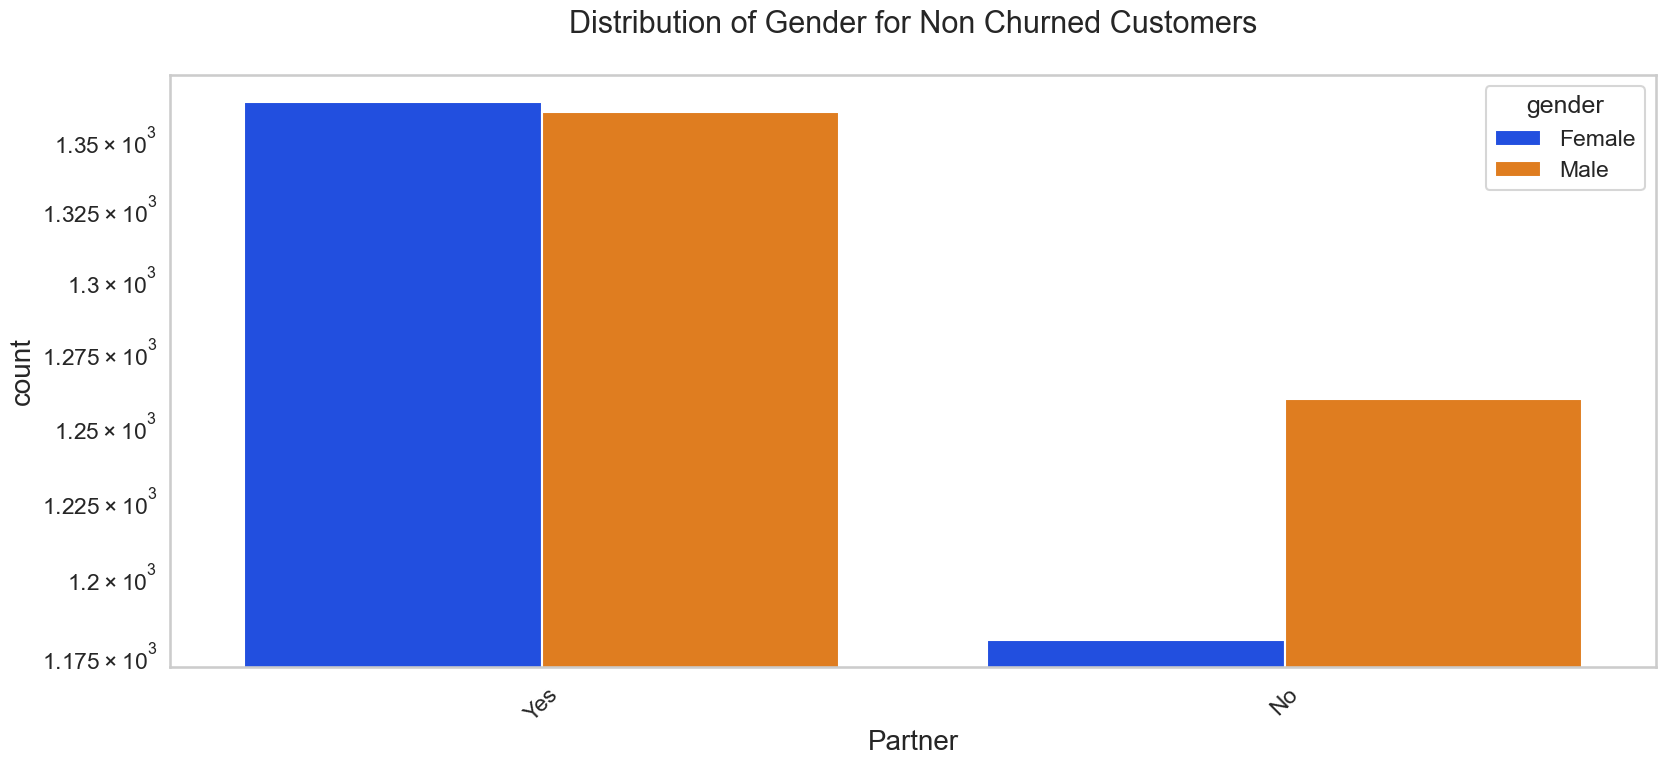

In [63]:
uniplot(new_df1_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


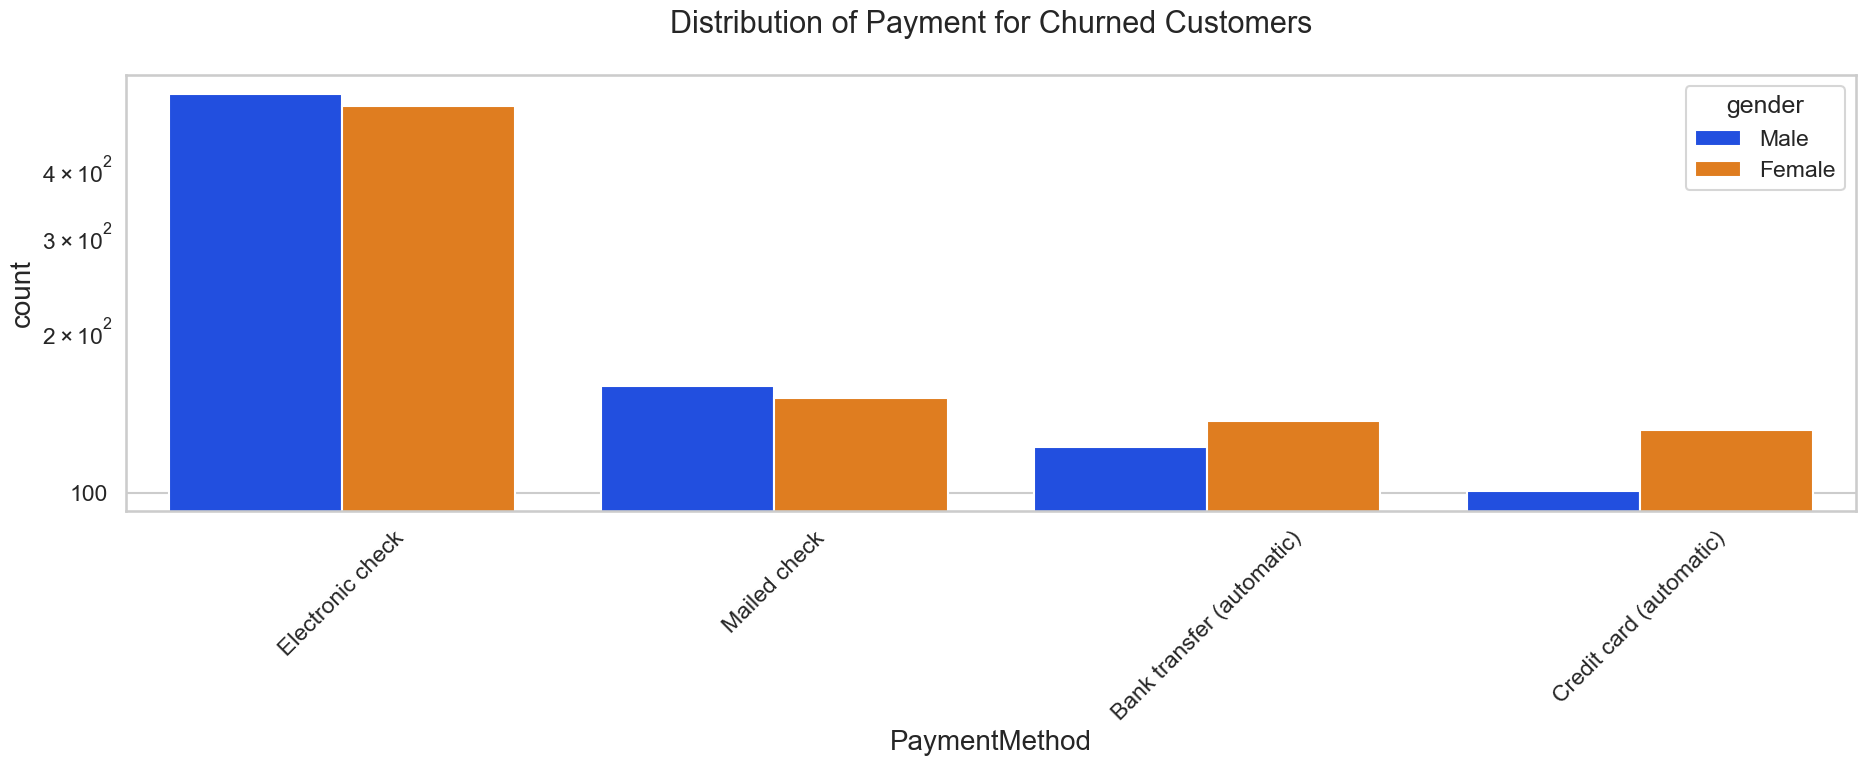

In [66]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of Payment for Churned Customers',hue='gender')

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


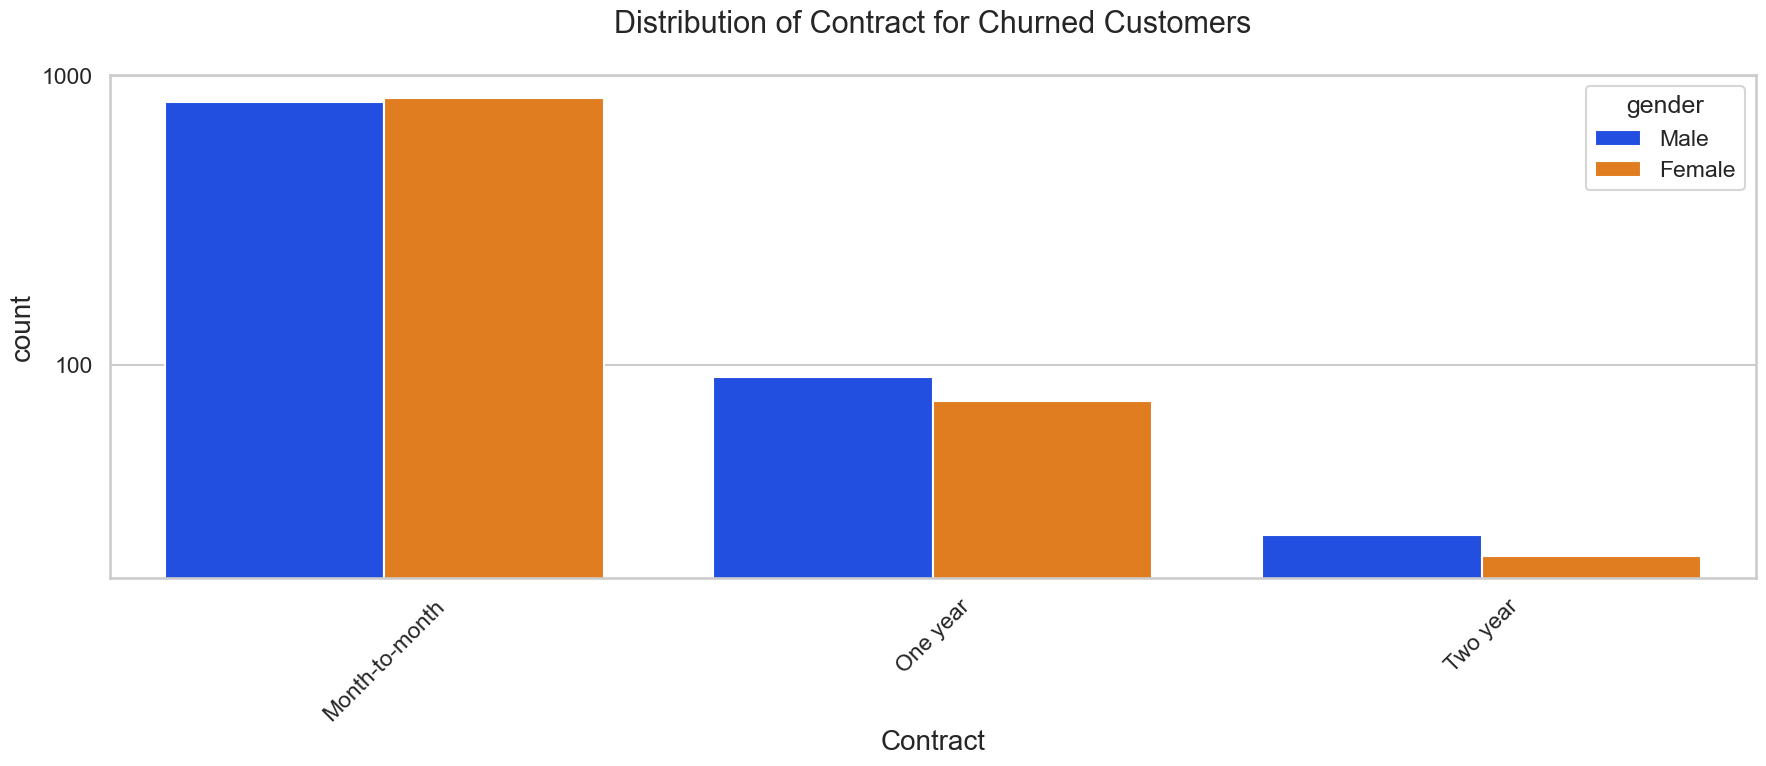

In [68]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customers',hue='gender')

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


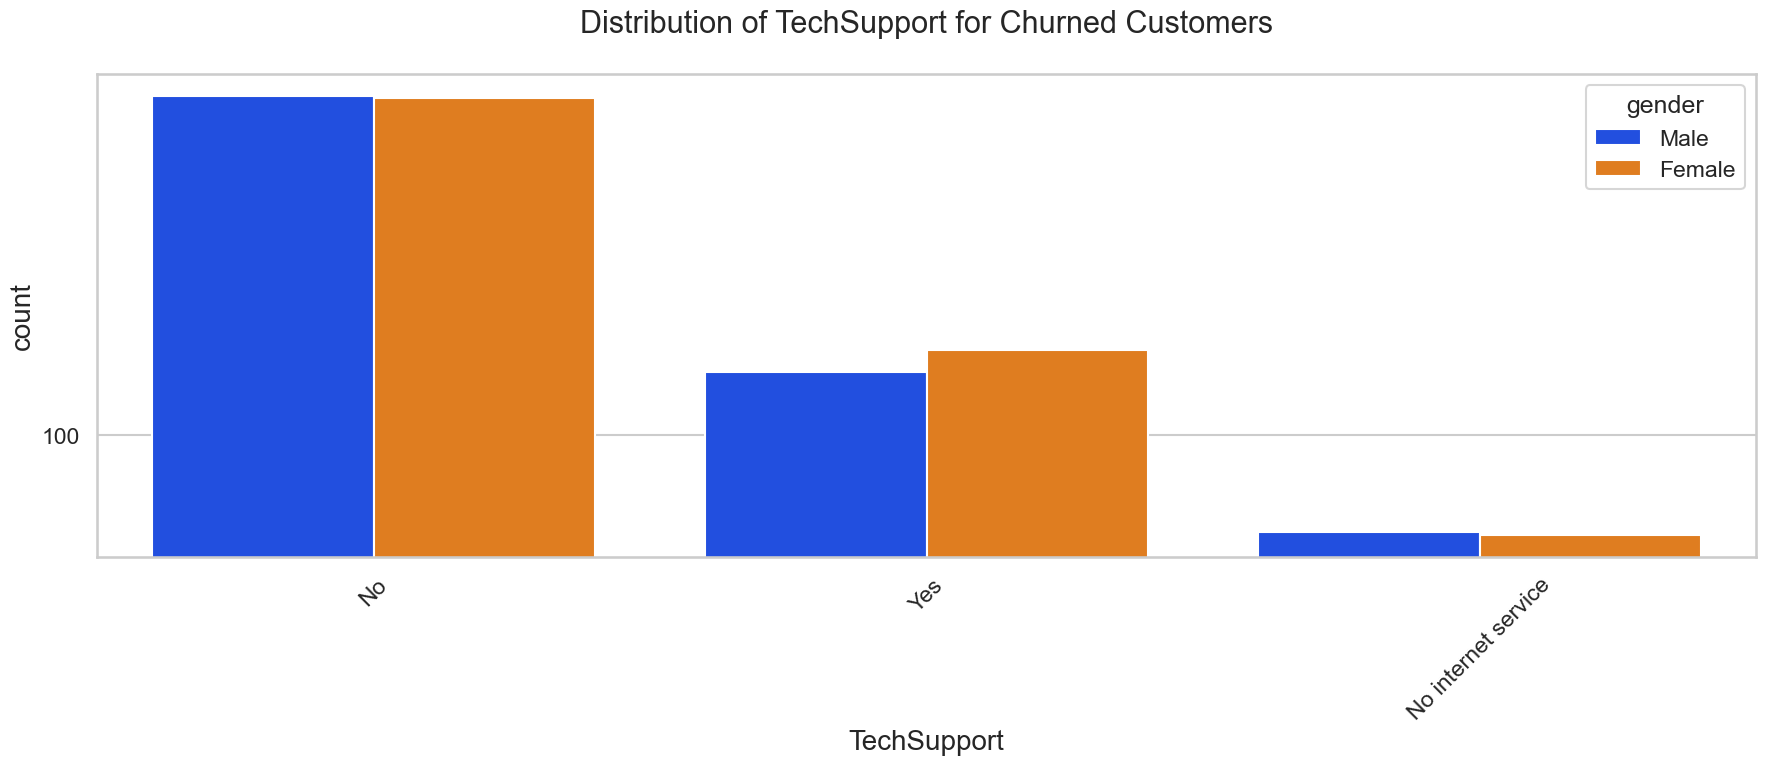

In [71]:
uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customers',hue='gender')

C:\Users\hp\AppData\Local\Temp\ipykernel_4936\1090559064.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


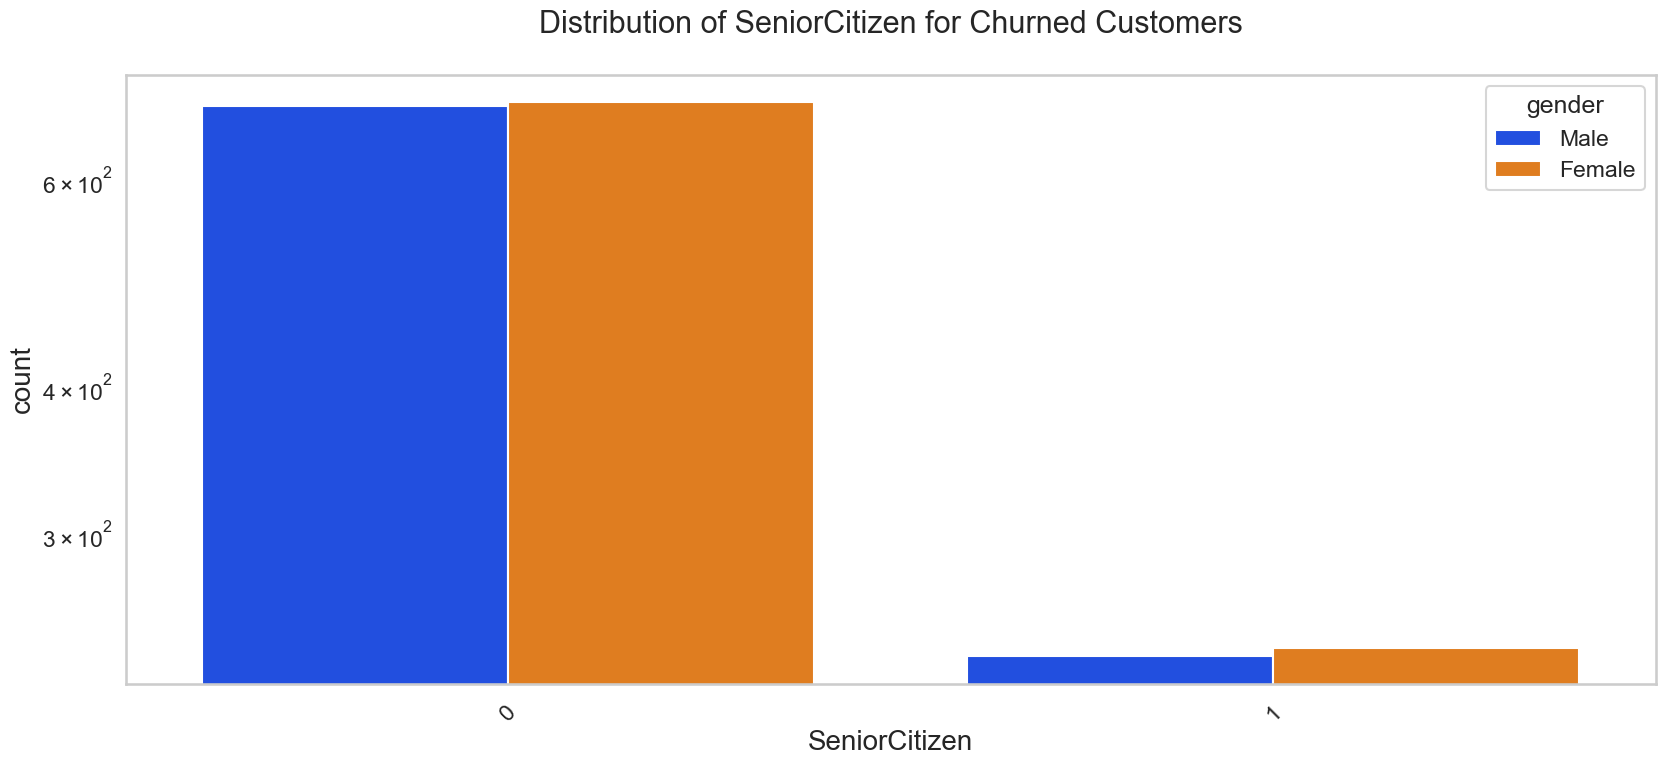

In [73]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customers',hue='gender')

CONCLUSION

There are some of the quick insights from this exercise
1. Electronic check medium are the highest churners 
2. Contract Type - Monthly are more likely to churn because of no contract terms, as they are free to go customers
3.No Online security, no tech support are high churners 
4. Non senior citizens are high churners 



In [74]:
tel_data_dummies.to_csv('tel_churn.csv')